<a href="https://colab.research.google.com/github/mohnish-2460git/Bank-Fraud-classification/blob/main/Fraud_Project_New.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub
import os

os.environ['KAGGLE_TOKEN'] = 'KGAT_57b06cb9c975e87864818f272eff616f'

path = kagglehub.dataset_download("sgpjesus/bank-account-fraud-dataset-neurips-2022")
print("Downloaded to:", path)

Using Colab cache for faster access to the 'bank-account-fraud-dataset-neurips-2022' dataset.
Downloaded to: /kaggle/input/bank-account-fraud-dataset-neurips-2022


In [ ]:
import pandas as pd
import os

# List files to find the exact filename
for f in os.listdir(path):
    print(f)

Base.csv
Variant IV.csv
Variant V.csv
Variant I.csv
Variant III.csv
Variant II.csv


In [ ]:
# Then load Variant I
df = pd.read_csv(os.path.join(path, 'Variant I.csv'))
print(df.shape)

(1000000, 32)


In [ ]:
import numpy as np

df=pd.read_csv('/kaggle/input/bank-account-fraud-dataset-neurips-2022/Variant I.csv')
print(df.head())

   fraud_bool  income  name_email_similarity  prev_address_months_count  \
0           0     0.9               0.990415                         11   
1           0     0.4               0.781728                         -1   
2           0     0.7               0.274290                         -1   
3           0     0.9               0.722684                         -1   
4           0     0.9               0.121661                         -1   

   current_address_months_count  customer_age  days_since_request  \
0                             4            40            0.014640   
1                           151            30            0.013269   
2                            92            20            0.010669   
3                            55            20            0.021849   
4                            51            20            0.021491   

   intended_balcon_amount payment_type  zip_count_4w  ...  has_other_cards  \
0               -0.897718           AC          1853  ..

In [ ]:
print(df.isnull().sum())

fraud_bool                          0
income                              0
name_email_similarity               0
prev_address_months_count           0
current_address_months_count        0
customer_age                        0
days_since_request                  0
intended_balcon_amount              0
payment_type                        0
zip_count_4w                        0
velocity_6h                         0
velocity_24h                        0
velocity_4w                         0
bank_branch_count_8w                0
date_of_birth_distinct_emails_4w    0
employment_status                   0
credit_risk_score                   0
email_is_free                       0
housing_status                      0
phone_home_valid                    0
phone_mobile_valid                  0
bank_months_count                   0
has_other_cards                     0
proposed_credit_limit               0
foreign_request                     0
source                              0
session_leng

In [ ]:
print(df.dtypes)

fraud_bool                            int64
income                              float64
name_email_similarity               float64
prev_address_months_count             int64
current_address_months_count          int64
customer_age                          int64
days_since_request                  float64
intended_balcon_amount              float64
payment_type                         object
zip_count_4w                          int64
velocity_6h                         float64
velocity_24h                        float64
velocity_4w                         float64
bank_branch_count_8w                  int64
date_of_birth_distinct_emails_4w      int64
employment_status                    object
credit_risk_score                     int64
email_is_free                         int64
housing_status                       object
phone_home_valid                      int64
phone_mobile_valid                    int64
bank_months_count                     int64
has_other_cards                 

Handle Duplicate Values

In [ ]:
from numpy._core.fromnumeric import shape
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

#handle duplicate values
before=df.shape[0]
df=df.drop_duplicates()
after=df.shape[0]
removed=before-after

print(f" Duplicates found & removed : {removed}")
print(f" Shape Before : ({before},{df.shape[1]})")
print(f" Shape after : {df.shape}")
print("  Status: Done ✓")



 Duplicates found & removed : 0
 Shape Before : (1000000,32)
 Shape after : (1000000, 32)
  Status: Done ✓


Handling sentinel values

In [ ]:
# Handling sentinel values

sentinel_cols=['prev_address_months_count','bank_months_count']

for col in sentinel_cols:
  Count=(df[col]==-1).sum()
  median_val=df[df[col] !=-1][col].median()
  df[col]=df[col].replace(-1,median_val)
  print(f"  {col}:")
  print(f" Sentinel(-1) count replaced : {Count}")
  print(f" Replaced with median : {median_val}")
  print("  Status: Done ✓")

  prev_address_months_count:
 Sentinel(-1) count replaced : 704367
 Replaced with median : 34.0
  Status: Done ✓
  bank_months_count:
 Sentinel(-1) count replaced : 254905
 Replaced with median : 15.0
  Status: Done ✓


Outlier Detection & Capping

In [ ]:
#outlier detection and capping
outlier_cols= [    'velocity_6h', 'velocity_24h', 'velocity_4w',
    'intended_balcon_amount', 'session_length_in_minutes',
    'days_since_request', 'zip_count_4w']
total_outliers=0
for col in outlier_cols:
  Q1=df[col].quantile(0.25)
  Q3=df[col].quantile(0.75)
  IQR=Q3-Q1
  lower=Q1-1.5*IQR
  upper=Q3+1.5*IQR
  outlier_count=((df[col]<lower)|(df[col]>upper)).sum()
  total_outliers+=outlier_count
  df[col]=df[col].clip(lower,upper)
  print(f"  {col}: {outlier_count} outliers capped")
  print(f"\n  Total outliers capped : {total_outliers}")
  print(f"  Shape remains         : {df.shape}")
  print("  Status: Done ✓")

  velocity_6h: 8497 outliers capped

  Total outliers capped : 8497
  Shape remains         : (1000000, 32)
  Status: Done ✓
  velocity_24h: 2736 outliers capped

  Total outliers capped : 11233
  Shape remains         : (1000000, 32)
  Status: Done ✓
  velocity_4w: 0 outliers capped

  Total outliers capped : 11233
  Shape remains         : (1000000, 32)
  Status: Done ✓
  intended_balcon_amount: 210504 outliers capped

  Total outliers capped : 221737
  Shape remains         : (1000000, 32)
  Status: Done ✓
  session_length_in_minutes: 78606 outliers capped

  Total outliers capped : 300343
  Shape remains         : (1000000, 32)
  Status: Done ✓
  days_since_request: 95052 outliers capped

  Total outliers capped : 395395
  Shape remains         : (1000000, 32)
  Status: Done ✓
  zip_count_4w: 57807 outliers capped

  Total outliers capped : 453202
  Shape remains         : (1000000, 32)
  Status: Done ✓


In [ ]:
#encoding categorical variables
categorical_cols=[ 'payment_type', 'employment_status',
    'housing_status', 'source', 'device_os']
le=LabelEncoder()
for col in categorical_cols:
  original_values=df[col].unique()
  df[col]=le.fit_transform(df[col])
  print(f" {col}:{list(original_values)}=>numeric")
print("  Status: Done ✓")

 payment_type:['AC', 'AA', 'AB', 'AD', 'AE']=>numeric
 employment_status:['CA', 'CF', 'CB', 'CD', 'CC', 'CE', 'CG']=>numeric
 housing_status:['BC', 'BB', 'BD', 'BE', 'BA', 'BG', 'BF']=>numeric
 source:['INTERNET', 'TELEAPP']=>numeric
 device_os:['windows', 'other', 'linux', 'macintosh', 'x11']=>numeric
  Status: Done ✓


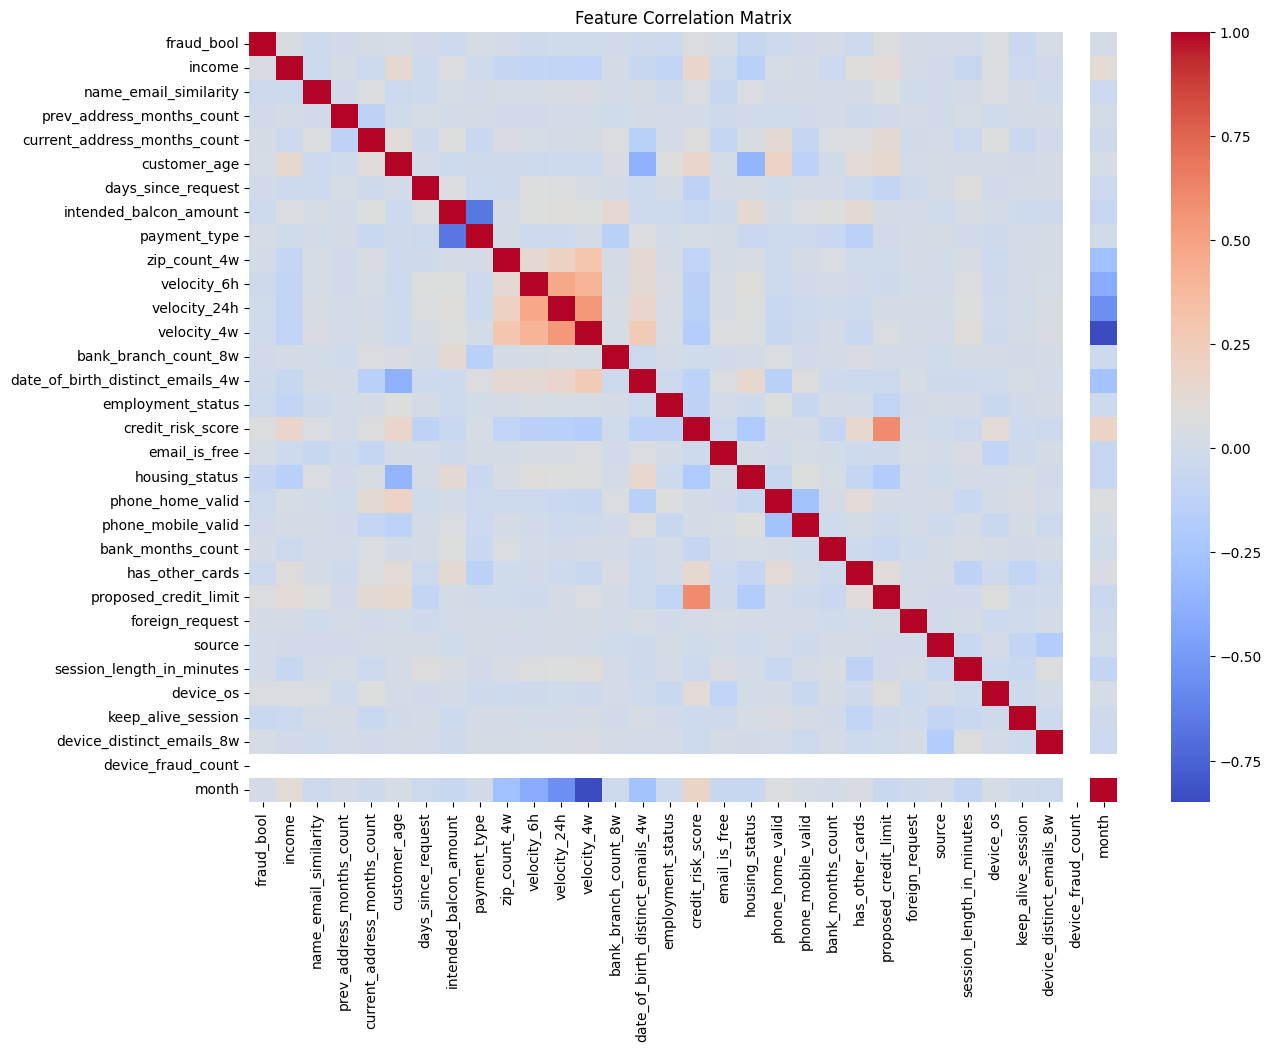

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(14,10))
corr_matrix=df.corr()
sns.heatmap(corr_matrix,annot=False, cmap='coolwarm')
plt.title('Feature Correlation Matrix')
plt.show()

In [ ]:
#Find Highly correlated pairs
high_corr=[]
for i in range(len(corr_matrix.columns)):
  for j in range(i):
    if abs(corr_matrix.iloc[i,j])>0.85:
      high_corr.append(corr_matrix.columns[i])
      print(f"High correlation: {corr_matrix.columns[j]} & {corr_matrix.columns[i]} = {corr_matrix.iloc[i,j]:.2f}")

#Drop highly correlated features
df_selected=df.drop(columns=high_corr)
print(f"\nFeatures before: 31")
print(f"Features after : {df_selected.shape[1]-1}")


Features before: 31
Features after : 31


  Training RF on sample for feature selection...

  Feature Importance Ranking:
                         Feature  Importance
               credit_risk_score    0.094300
           name_email_similarity    0.068395
              days_since_request    0.062332
                     velocity_4w    0.054320
                     velocity_6h    0.053750
date_of_birth_distinct_emails_4w    0.049607
                  housing_status    0.049389
          intended_balcon_amount    0.049045
    current_address_months_count    0.047467
                    zip_count_4w    0.046516
                    velocity_24h    0.045355
            bank_branch_count_8w    0.042937
                       device_os    0.041428
       session_length_in_minutes    0.041135
           proposed_credit_limit    0.038468
                          income    0.033186
       device_distinct_emails_8w    0.021657
                           month    0.019797
               bank_months_count    0.018172
                    

/tmp/ipykernel_699/2938169576.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


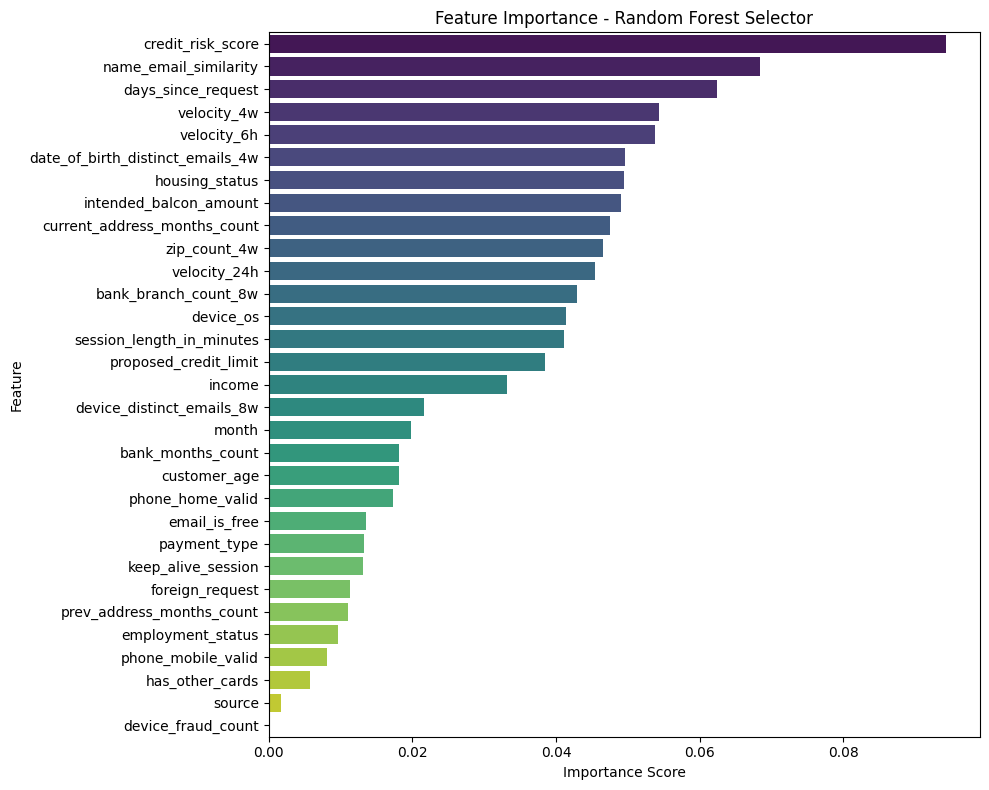


  Features kept (importance > 1%) : 26
  Selected features               : ['credit_risk_score', 'name_email_similarity', 'days_since_request', 'velocity_4w', 'velocity_6h', 'date_of_birth_distinct_emails_4w', 'housing_status', 'intended_balcon_amount', 'current_address_months_count', 'zip_count_4w', 'velocity_24h', 'bank_branch_count_8w', 'device_os', 'session_length_in_minutes', 'proposed_credit_limit', 'income', 'device_distinct_emails_8w', 'month', 'bank_months_count', 'customer_age', 'phone_home_valid', 'email_is_free', 'payment_type', 'keep_alive_session', 'foreign_request', 'prev_address_months_count']
  Shape after feature selection   : (1000000, 26)
  Status: Done ✓


In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Separate features and target from current df
# (after encoding, outlier capping, sentinel handling)
X_raw = df.drop('fraud_bool', axis=1)
y_raw = df['fraud_bool']

# Use 50,000 sample for speed (no need for full 1M rows)
sample_idx = df.sample(n=50000, random_state=42).index
X_sample   = X_raw.loc[sample_idx]
y_sample   = y_raw.loc[sample_idx]

print("  Training RF on sample for feature selection...")
rf_selector = RandomForestClassifier(
    n_estimators = 50,
    max_depth    = 8,
    random_state = 42,
    n_jobs       = -1
)
rf_selector.fit(X_sample, y_sample)

# Feature importance
importance_df = pd.DataFrame({
    'Feature'   : X_raw.columns,
    'Importance': rf_selector.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n  Feature Importance Ranking:")
print(importance_df.to_string(index=False))

# Plot
plt.figure(figsize=(10,8))
sns.barplot(
    x='Importance', y='Feature',
    data=importance_df, palette='viridis'
)
plt.title('Feature Importance - Random Forest Selector')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('feature_importance_selection.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Keep features with importance > 0.01 (1%)
selected_features = importance_df[
    importance_df['Importance'] > 0.01
]['Feature'].tolist()

print(f"\n  Features kept (importance > 1%) : {len(selected_features)}")
print(f"  Selected features               : {selected_features}")

# Apply selection to full df
X_raw = X_raw[selected_features]
print(f"  Shape after feature selection   : {X_raw.shape}")
print("  Status: Done ✓")


In [ ]:
#separate features and target
X=X_raw
y=df['fraud_bool']

print(f"  Features used : {X.shape[1]}")
print(f"\n  Class distribution BEFORE SMOTE:")
print(f"    Non-Fraud (0) : {(y==0).sum()}")
print(f" Fraud (1) : {(y==1).sum()}")
print(f" Fraud Rate : {y.mean()*100:.2f}%")

#train/test split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,
                                               random_state=42,
                                               stratify=y)
#keeps fraud ratio same in both splits

print(f"\n  Train/Test Split (80/20):")
print(f"    Training set  : {X_train.shape}")
print(f"    Test set      : {X_test.shape}")

  Features used : 26

  Class distribution BEFORE SMOTE:
    Non-Fraud (0) : 988971
 Fraud (1) : 11029
 Fraud Rate : 1.10%

  Train/Test Split (80/20):
    Training set  : (800000, 26)
    Test set      : (200000, 26)


In [ ]:
from imblearn.over_sampling import SMOTE

# Feature Scaling
scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
print(f"\n  StandardScaler applied ✓")

# SMOTE - training set only
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(
    X_train_scaled, y_train
)

print(f"\n  Class distribution AFTER SMOTE (training set):")
print(f"    Non-Fraud (0) : {(y_train_resampled==0).sum()}")
print(f"    Fraud     (1) : {(y_train_resampled==1).sum()}")
print(f"    Fraud rate    : {pd.Series(y_train_resampled).mean()*100:.2f}%")

print(f"\n  Final shapes:")
print(f"    X_train : {X_train_resampled.shape}")  # should show 26 columns
print(f"    X_test  : {X_test_scaled.shape}")       # should show 26 columns
print("  Status: Done ✓")


  StandardScaler applied ✓

  Class distribution AFTER SMOTE (training set):
    Non-Fraud (0) : 791177
    Fraud     (1) : 791177
    Fraud rate    : 50.00%

  Final shapes:
    X_train : (1582354, 26)
    X_test  : (200000, 26)
  Status: Done ✓


In [ ]:
import xgboost as xgb
import time
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             roc_auc_score, confusion_matrix,
                             classification_report,
                             precision_recall_curve, RocCurveDisplay)

X_train_df = pd.DataFrame(X_train_resampled, columns=X.columns)
X_test_df  = pd.DataFrame(X_test_scaled, columns=X.columns)

print(f"  X_train_df : {X_train_df.shape}")
print(f"  X_test_df  : {X_test_df.shape}")
print("\n>>> Training XGBoost...")

# Calculate scale weight for imbalance
scale_weight = (y_train_resampled==0).sum() / (y_train_resampled==1).sum()

start     = time.time()
xgb_model = xgb.XGBClassifier(
    n_estimators      = 500,
    learning_rate     = 0.05,
    max_depth         = 8,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    reg_alpha         = 0.1,
    reg_lambda        = 0.1,
    scale_pos_weight  = scale_weight,
    random_state      = 42,
    n_jobs            = -1,
    eval_metric       = 'auc',
    verbosity         = 0
)
xgb_model.fit(
    X_train_df, y_train_resampled,
    eval_set        = [(X_test_df, y_test)],
    verbose         = False
)
xgb_time = time.time() - start

print(f"  Training time : {xgb_time:.2f} seconds")
print("  Status: Done ✓")



  X_train_df : (1582354, 26)
  X_test_df  : (200000, 26)

>>> Training XGBoost...
  Training time : 170.63 seconds
  Status: Done ✓


In [ ]:
xgb_pred_prob = xgb_model.predict_proba(X_test_df)[:,1]

# Find best threshold
precisions, recalls, thresholds = precision_recall_curve(
    y_test, xgb_pred_prob
)
f1_scores      = 2*(precisions*recalls)/(precisions+recalls+1e-8)
best_idx       = f1_scores.argmax()
best_threshold = thresholds[best_idx]

print(f"\n  Best threshold : {best_threshold:.4f}")
print(f"  Best F1-Score  : {f1_scores[best_idx]*100:.2f}%")

# Apply threshold
xgb_pred = (xgb_pred_prob >= best_threshold).astype(int)

print("\n>>> Evaluation Metrics:")
print(f"  Accuracy  : {accuracy_score(y_test, xgb_pred)*100:.2f}%")
print(f"  Precision : {precision_score(y_test, xgb_pred)*100:.2f}%")
print(f"  Recall    : {recall_score(y_test, xgb_pred)*100:.2f}%")
print(f"  F1-Score  : {f1_score(y_test, xgb_pred)*100:.2f}%")
print(f"  ROC-AUC   : {roc_auc_score(y_test, xgb_pred_prob)*100:.2f}%")

print("\n>>> Classification Report:")
print(classification_report(y_test, xgb_pred,
      target_names=['Non-Fraud', 'Fraud']))


  Best threshold : 0.1281
  Best F1-Score  : 19.38%

>>> Evaluation Metrics:
  Accuracy  : 97.39%
  Precision : 14.71%
  Recall    : 28.42%
  F1-Score  : 19.38%
  ROC-AUC   : 86.37%

>>> Classification Report:
              precision    recall  f1-score   support

   Non-Fraud       0.99      0.98      0.99    197794
       Fraud       0.15      0.28      0.19      2206

    accuracy                           0.97    200000
   macro avg       0.57      0.63      0.59    200000
weighted avg       0.98      0.97      0.98    200000



CONFUSION MATRIX

>>> Confusion Matrix Breakdown:
  True Negative  (TN) : 194,158  ← Non-fraud correctly identified
  False Positive (FP) : 3,636  ← Non-fraud wrongly flagged as fraud
  False Negative (FN) : 1,579  ← Fraud MISSED by model
  True Positive  (TP) : 627  ← Fraud correctly caught

  Total actual frauds  : 2,206
  Frauds caught        : 627 (28.42%)
  Frauds missed        : 1,579 (71.58%)


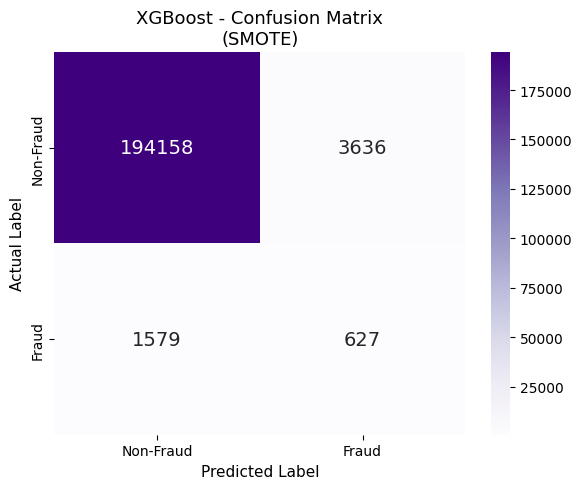

Confusion matrix saved ✓



In [ ]:
plt.figure(figsize=(6,5))
cm = confusion_matrix(y_test, xgb_pred)

# Extract values
TN = cm[0][0]
FP = cm[0][1]
FN = cm[1][0]
TP = cm[1][1]

print(">>> Confusion Matrix Breakdown:")
print(f"  True Negative  (TN) : {TN:,}  ← Non-fraud correctly identified")
print(f"  False Positive (FP) : {FP:,}  ← Non-fraud wrongly flagged as fraud")
print(f"  False Negative (FN) : {FN:,}  ← Fraud MISSED by model")
print(f"  True Positive  (TP) : {TP:,}  ← Fraud correctly caught")
print(f"\n  Total actual frauds  : {TP+FN:,}")
print(f"  Frauds caught        : {TP:,} ({TP/(TP+FN)*100:.2f}%)")
print(f"  Frauds missed        : {FN:,} ({FN/(TP+FN)*100:.2f}%)")

sns.heatmap(
    cm, annot=True, fmt='d',
    cmap='Purples',
    xticklabels=['Non-Fraud', 'Fraud'],
    yticklabels=['Non-Fraud', 'Fraud'],
    annot_kws={'size': 14}
)
plt.title('XGBoost - Confusion Matrix\n(SMOTE)', fontsize=13)
plt.xlabel('Predicted Label', fontsize=11)
plt.ylabel('Actual Label', fontsize=11)
plt.tight_layout()
plt.savefig('xgb_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Confusion matrix saved ✓\n")


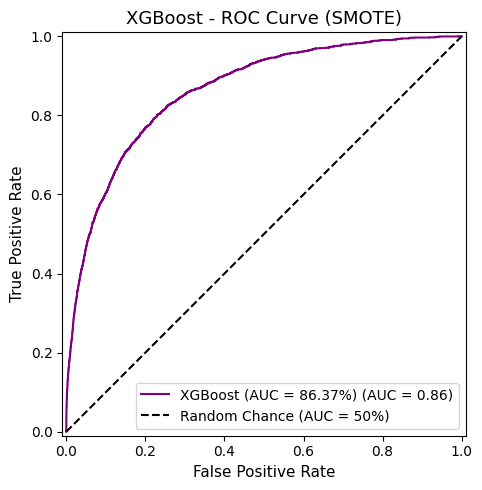

ROC curve saved ✓



In [ ]:
fig, ax = plt.subplots(figsize=(7,5))
RocCurveDisplay.from_predictions(
    y_test, xgb_pred_prob,
    name=f'XGBoost (AUC = {roc_auc_score(y_test, xgb_pred_prob)*100:.2f}%)',
    ax=ax, color='purple'
)
ax.plot([0,1], [0,1], 'k--', label='Random Chance (AUC = 50%)')
ax.set_title('XGBoost - ROC Curve (SMOTE)', fontsize=13)
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('xgb_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("ROC curve saved ✓\n")

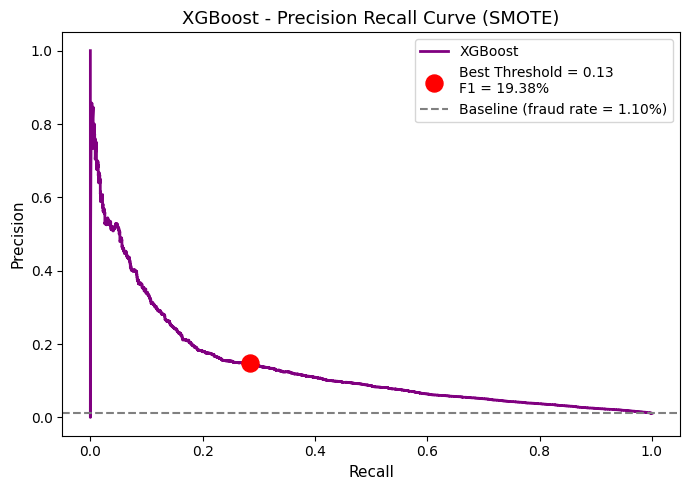

Precision Recall curve saved ✓



In [ ]:
precisions, recalls, thresholds = precision_recall_curve(
    y_test, xgb_pred_prob
)
f1_scores  = 2*(precisions*recalls)/(precisions+recalls+1e-8)
best_idx   = f1_scores.argmax()

plt.figure(figsize=(7,5))
plt.plot(recalls, precisions,
         color='purple', lw=2,
         label='XGBoost')
plt.scatter(
    recalls[best_idx], precisions[best_idx],
    color='red', s=150, zorder=5,
    label=f'Best Threshold = {best_threshold:.2f}\nF1 = {f1_scores[best_idx]*100:.2f}%'
)
plt.axhline(
    y=y_test.mean(), color='gray',
    linestyle='--',
    label=f'Baseline (fraud rate = {y_test.mean()*100:.2f}%)'
)
plt.xlabel('Recall', fontsize=11)
plt.ylabel('Precision', fontsize=11)
plt.title('XGBoost - Precision Recall Curve (SMOTE)', fontsize=13)
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig('xgb_precision_recall.png', dpi=150, bbox_inches='tight')
plt.show()
print("Precision Recall curve saved ✓\n")

In [ ]:
print("\n" + "="*55)
print("  XGBoost - FINAL SUMMARY (SMOTE)")
print("="*55)
print(f"  Features used   : {X.shape[1]}")
print(f"  Training size   : {X_train_resampled.shape[0]:,} rows (after SMOTE)")
print(f"  Test size       : {X_test_scaled.shape[0]:,} rows")
print(f"  Best Threshold  : {best_threshold:.4f}")
print(f"  Accuracy        : {accuracy_score(y_test, xgb_pred)*100:.2f}%")
print(f"  Precision       : {precision_score(y_test, xgb_pred)*100:.2f}%")
print(f"  Recall          : {recall_score(y_test, xgb_pred)*100:.2f}%")
print(f"  F1-Score        : {f1_score(y_test, xgb_pred)*100:.2f}%")
print(f"  ROC-AUC         : {roc_auc_score(y_test, xgb_pred_prob)*100:.2f}%")
print(f"\n  Confusion Matrix:")
print(f"  True Negative  (TN) : {TN:,}")
print(f"  False Positive (FP) : {FP:,}")
print(f"  False Negative (FN) : {FN:,}")
print(f"  True Positive  (TP) : {TP:,}")
print(f"\n  Frauds correctly caught : {TP:,} / {TP+FN:,}")
print(f"  Frauds missed           : {FN:,} / {TP+FN:,}")
print("="*55)


  XGBoost - FINAL SUMMARY (SMOTE)
  Features used   : 26
  Training size   : 1,582,354 rows (after SMOTE)
  Test size       : 200,000 rows
  Best Threshold  : 0.1281
  Accuracy        : 97.39%
  Precision       : 14.71%
  Recall          : 28.42%
  F1-Score        : 19.38%
  ROC-AUC         : 86.37%

  Confusion Matrix:
  True Negative  (TN) : 194,158
  False Positive (FP) : 3,636
  False Negative (FN) : 1,579
  True Positive  (TP) : 627

  Frauds correctly caught : 627 / 2,206
  Frauds missed           : 1,579 / 2,206


Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics  import (classification_report,
                              confusion_matrix,
                              accuracy_score,
                              precision_score,
                              recall_score,
                              f1_score,
                              roc_auc_score,
                              precision_recall_curve,
                              RocCurveDisplay)

start   = time.time()
base_rf = RandomForestClassifier(
    n_estimators      = 100,
    max_depth         = 10,
    random_state      = 42,
    n_jobs            = -1
)
base_rf.fit(X_train_resampled, y_train_resampled)
rf_time = time.time() - start

print(f"  Training time : {rf_time:.2f} seconds")
print("  Status: Done ✓")

  Training time : 741.34 seconds
  Status: Done ✓


In [ ]:
rf_pred_prob = base_rf.predict_proba(X_test_scaled)[:,1]

# Find best threshold using F1
precisions, recalls, thresholds = precision_recall_curve(
    y_test, rf_pred_prob
)
f1_scores      = 2*(precisions*recalls)/(precisions+recalls+1e-8)
best_idx       = f1_scores.argmax()
best_threshold = thresholds[best_idx]

print(f"\n  Best threshold : {best_threshold:.4f}")
print(f"  Best F1-Score  : {f1_scores[best_idx]*100:.2f}%")

# Apply best threshold
rf_pred = (rf_pred_prob >= best_threshold).astype(int)

print("\n>>> Evaluation Metrics:")
print(f"  Accuracy  : {accuracy_score(y_test, rf_pred)*100:.2f}%")
print(f"  Precision : {precision_score(y_test, rf_pred)*100:.2f}%")
print(f"  Recall    : {recall_score(y_test, rf_pred)*100:.2f}%")
print(f"  F1-Score  : {f1_score(y_test, rf_pred)*100:.2f}%")
print(f"  ROC-AUC   : {roc_auc_score(y_test, rf_pred_prob)*100:.2f}%")

print("\n>>> Classification Report:")
print(classification_report(y_test, rf_pred,
      target_names=['Non-Fraud', 'Fraud']))


  Best threshold : 0.7400
  Best F1-Score  : 16.74%

>>> Evaluation Metrics:
  Accuracy  : 97.83%
  Precision : 14.49%
  Recall    : 19.81%
  F1-Score  : 16.74%
  ROC-AUC   : 83.45%

>>> Classification Report:
              precision    recall  f1-score   support

   Non-Fraud       0.99      0.99      0.99    197794
       Fraud       0.14      0.20      0.17      2206

    accuracy                           0.98    200000
   macro avg       0.57      0.59      0.58    200000
weighted avg       0.98      0.98      0.98    200000



>>> Confusion Matrix Breakdown:
  True Negative  (TN) : 195,215 ← Non-fraud correctly identified
  False Positive (FP) : 2,579 ← Non-fraud wrongly flagged
  False Negative (FN) : 1,769 ← Fraud MISSED
  True Positive  (TP) : 437 ← Fraud correctly caught

  Frauds caught : 437 / 2,206
  Frauds missed : 1,769 / 2,206


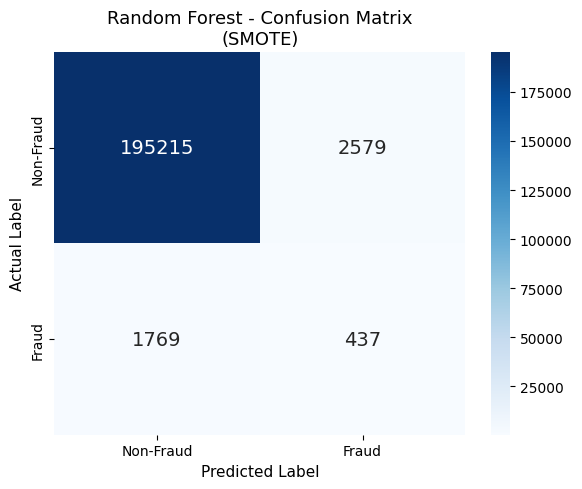

Confusion matrix saved ✓


In [ ]:
plt.figure(figsize=(6,5))
cm = confusion_matrix(y_test, rf_pred)

TN = cm[0][0]
FP = cm[0][1]
FN = cm[1][0]
TP = cm[1][1]

print(">>> Confusion Matrix Breakdown:")
print(f"  True Negative  (TN) : {TN:,} ← Non-fraud correctly identified")
print(f"  False Positive (FP) : {FP:,} ← Non-fraud wrongly flagged")
print(f"  False Negative (FN) : {FN:,} ← Fraud MISSED")
print(f"  True Positive  (TP) : {TP:,} ← Fraud correctly caught")
print(f"\n  Frauds caught : {TP:,} / {TP+FN:,}")
print(f"  Frauds missed : {FN:,} / {TP+FN:,}")

sns.heatmap(
    cm, annot=True, fmt='d',
    cmap='Blues',
    xticklabels=['Non-Fraud', 'Fraud'],
    yticklabels=['Non-Fraud', 'Fraud'],
    annot_kws={'size': 14}
)
plt.title('Random Forest - Confusion Matrix\n(SMOTE)', fontsize=13)
plt.xlabel('Predicted Label', fontsize=11)
plt.ylabel('Actual Label', fontsize=11)
plt.tight_layout()
plt.savefig('rf_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Confusion matrix saved ✓")

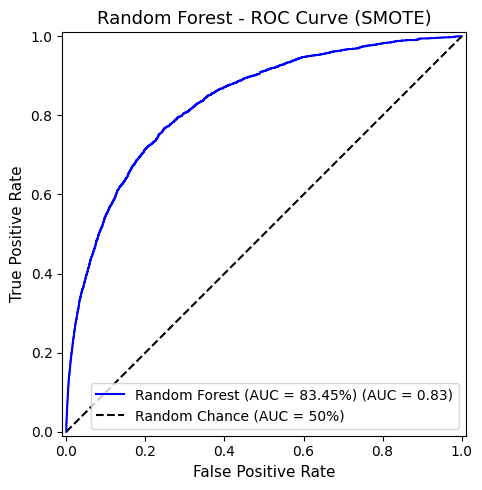

ROC curve saved ✓


In [ ]:
fig, ax = plt.subplots(figsize=(7,5))
RocCurveDisplay.from_predictions(
    y_test, rf_pred_prob,
    name=f'Random Forest (AUC = {roc_auc_score(y_test, rf_pred_prob)*100:.2f}%)',
    ax=ax, color='blue'
)
ax.plot([0,1], [0,1], 'k--', label='Random Chance (AUC = 50%)')
ax.set_title('Random Forest - ROC Curve (SMOTE)', fontsize=13)
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('rf_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("ROC curve saved ✓")

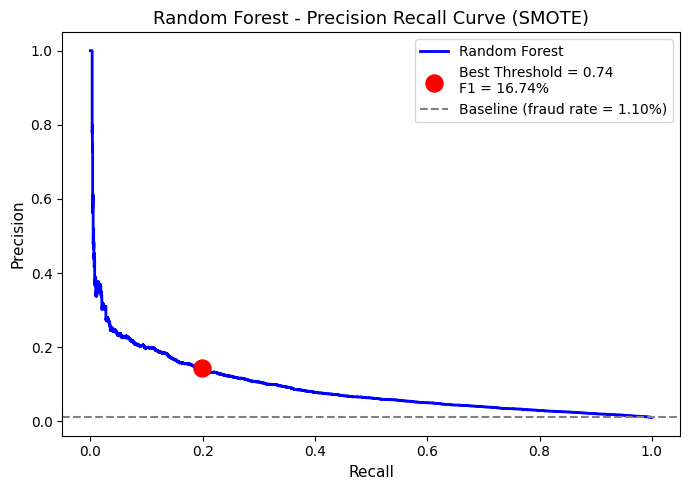

Precision Recall curve saved ✓


In [ ]:
plt.figure(figsize=(7,5))
plt.plot(recalls, precisions,
         color='blue', lw=2,
         label='Random Forest')
plt.scatter(
    recalls[best_idx], precisions[best_idx],
    color='red', s=150, zorder=5,
    label=f'Best Threshold = {best_threshold:.2f}\nF1 = {f1_scores[best_idx]*100:.2f}%'
)
plt.axhline(
    y=y_test.mean(), color='gray',
    linestyle='--',
    label=f'Baseline (fraud rate = {y_test.mean()*100:.2f}%)'
)
plt.xlabel('Recall', fontsize=11)
plt.ylabel('Precision', fontsize=11)
plt.title('Random Forest - Precision Recall Curve (SMOTE)', fontsize=13)
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig('rf_precision_recall.png', dpi=150, bbox_inches='tight')
plt.show()
print("Precision Recall curve saved ✓")


In [ ]:
print("\n" + "="*55)
print("  RANDOM FOREST - FINAL SUMMARY (SMOTE)")
print("="*55)
print(f"  Features used   : {X.shape[1]}")
print(f"  Training size   : {X_train_resampled.shape[0]:,} rows (after SMOTE)")
print(f"  Test size       : {X_test_scaled.shape[0]:,} rows")
print(f"  Best Threshold  : {best_threshold:.4f}")
print(f"  Accuracy        : {accuracy_score(y_test, rf_pred)*100:.2f}%")
print(f"  Precision       : {precision_score(y_test, rf_pred)*100:.2f}%")
print(f"  Recall          : {recall_score(y_test, rf_pred)*100:.2f}%")
print(f"  F1-Score        : {f1_score(y_test, rf_pred)*100:.2f}%")
print(f"  ROC-AUC         : {roc_auc_score(y_test, rf_pred_prob)*100:.2f}%")
print(f"\n  Confusion Matrix:")
print(f"  True Negative  (TN) : {TN:,}")
print(f"  False Positive (FP) : {FP:,}")
print(f"  False Negative (FN) : {FN:,}")
print(f"  True Positive  (TP) : {TP:,}")
print(f"\n  Frauds correctly caught : {TP:,} / {TP+FN:,}")
print(f"  Frauds missed           : {FN:,} / {TP+FN:,}")
print("="*55)


  RANDOM FOREST - FINAL SUMMARY (SMOTE)
  Features used   : 26
  Training size   : 1,582,354 rows (after SMOTE)
  Test size       : 200,000 rows
  Best Threshold  : 0.7400
  Accuracy        : 97.83%
  Precision       : 14.49%
  Recall          : 19.81%
  F1-Score        : 16.74%
  ROC-AUC         : 83.45%

  Confusion Matrix:
  True Negative  (TN) : 195,215
  False Positive (FP) : 2,579
  False Negative (FN) : 1,769
  True Positive  (TP) : 437

  Frauds correctly caught : 437 / 2,206
  Frauds missed           : 1,769 / 2,206


Decision Tree

In [ ]:
from sklearn.tree    import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             roc_auc_score, confusion_matrix,
                             classification_report,
                             precision_recall_curve,
                             RocCurveDisplay)
print(">>> Training Decision Tree...")

start    = time.time()
dt_model = DecisionTreeClassifier(
    max_depth         = 10,
    min_samples_split = 20,
    random_state      = 42
)
dt_model.fit(X_train_resampled, y_train_resampled)
dt_time  = time.time() - start

print(f"  Training time : {dt_time:.2f} seconds")
print("  Status: Done ✓")

>>> Training Decision Tree...
  Training time : 67.49 seconds
  Status: Done ✓


In [ ]:
dt_pred_prob = dt_model.predict_proba(X_test_scaled)[:,1]

# Find best threshold using F1
precisions, recalls, thresholds = precision_recall_curve(
    y_test, dt_pred_prob
)
f1_scores      = 2*(precisions*recalls)/(precisions+recalls+1e-8)
best_idx       = f1_scores.argmax()
best_threshold = thresholds[best_idx]

print(f"\n  Best threshold : {best_threshold:.4f}")
print(f"  Best F1-Score  : {f1_scores[best_idx]*100:.2f}%")

# Apply best threshold
dt_pred = (dt_pred_prob >= best_threshold).astype(int)

print("\n>>> Evaluation Metrics:")
print(f"  Accuracy  : {accuracy_score(y_test, dt_pred)*100:.2f}%")
print(f"  Precision : {precision_score(y_test, dt_pred)*100:.2f}%")
print(f"  Recall    : {recall_score(y_test, dt_pred)*100:.2f}%")
print(f"  F1-Score  : {f1_score(y_test, dt_pred)*100:.2f}%")
print(f"  ROC-AUC   : {roc_auc_score(y_test, dt_pred_prob)*100:.2f}%")

print("\n>>> Classification Report:")
print(classification_report(y_test, dt_pred,
      target_names=['Non-Fraud', 'Fraud']))



  Best threshold : 0.7536
  Best F1-Score  : 14.38%

>>> Evaluation Metrics:
  Accuracy  : 97.37%
  Precision : 11.22%
  Recall    : 20.04%
  F1-Score  : 14.38%
  ROC-AUC   : 78.11%

>>> Classification Report:
              precision    recall  f1-score   support

   Non-Fraud       0.99      0.98      0.99    197794
       Fraud       0.11      0.20      0.14      2206

    accuracy                           0.97    200000
   macro avg       0.55      0.59      0.57    200000
weighted avg       0.98      0.97      0.98    200000



>>> Confusion Matrix Breakdown:
  True Negative  (TN) : 194,296 ← Non-fraud correctly identified
  False Positive (FP) : 3,498 ← Non-fraud wrongly flagged
  False Negative (FN) : 1,764 ← Fraud MISSED
  True Positive  (TP) : 442 ← Fraud correctly caught

  Frauds caught : 442 / 2,206
  Frauds missed : 1,764 / 2,206


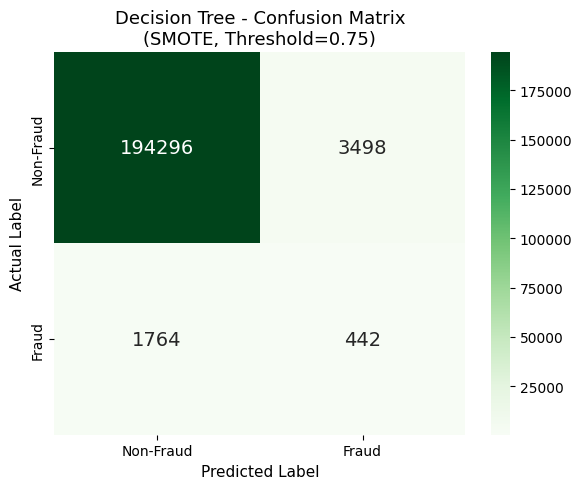

Confusion matrix saved ✓


In [ ]:
cm = confusion_matrix(y_test, dt_pred)
TN = cm[0][0]
FP = cm[0][1]
FN = cm[1][0]
TP = cm[1][1]

print(">>> Confusion Matrix Breakdown:")
print(f"  True Negative  (TN) : {TN:,} ← Non-fraud correctly identified")
print(f"  False Positive (FP) : {FP:,} ← Non-fraud wrongly flagged")
print(f"  False Negative (FN) : {FN:,} ← Fraud MISSED")
print(f"  True Positive  (TP) : {TP:,} ← Fraud correctly caught")
print(f"\n  Frauds caught : {TP:,} / {TP+FN:,}")
print(f"  Frauds missed : {FN:,} / {TP+FN:,}")

plt.figure(figsize=(6,5))
sns.heatmap(
    cm, annot=True, fmt='d',
    cmap='Greens',
    xticklabels=['Non-Fraud', 'Fraud'],
    yticklabels=['Non-Fraud', 'Fraud'],
    annot_kws={'size': 14}
)
plt.title(f'Decision Tree - Confusion Matrix\n(SMOTE, Threshold={best_threshold:.2f})',
          fontsize=13)
plt.xlabel('Predicted Label', fontsize=11)
plt.ylabel('Actual Label', fontsize=11)
plt.tight_layout()
plt.savefig('dt_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Confusion matrix saved ✓")


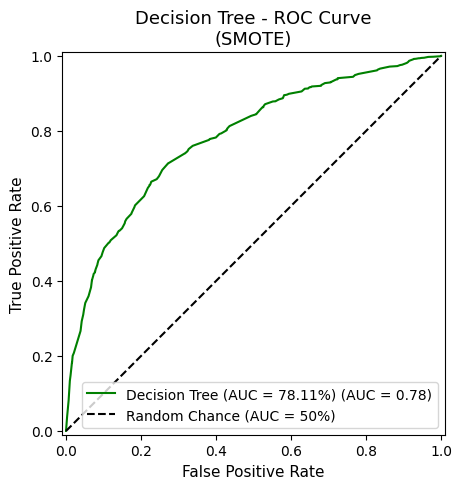

ROC curve saved ✓


In [ ]:
fig, ax = plt.subplots(figsize=(7,5))
RocCurveDisplay.from_predictions(
    y_test, dt_pred_prob,
    name=f'Decision Tree (AUC = {roc_auc_score(y_test, dt_pred_prob)*100:.2f}%)',
    ax=ax, color='green'
)
ax.plot([0,1], [0,1], 'k--', label='Random Chance (AUC = 50%)')
ax.set_title('Decision Tree - ROC Curve\n(SMOTE)', fontsize=13)
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('dt_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("ROC curve saved ✓")


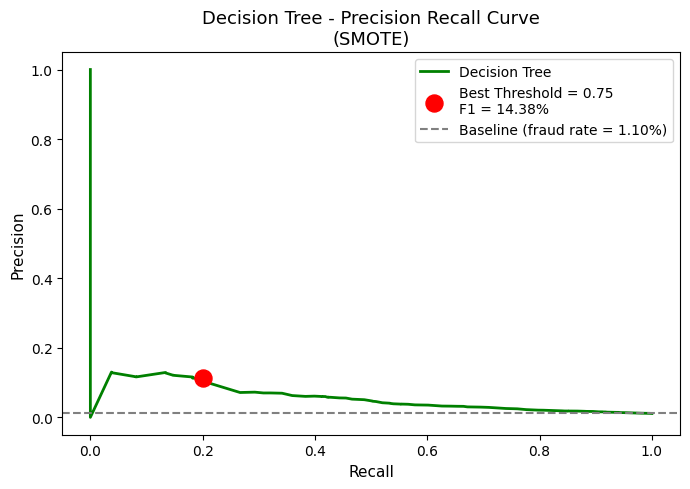

Precision Recall curve saved ✓


In [ ]:
plt.figure(figsize=(7,5))
plt.plot(recalls, precisions,
         color='green', lw=2,
         label='Decision Tree')
plt.scatter(
    recalls[best_idx], precisions[best_idx],
    color='red', s=150, zorder=5,
    label=f'Best Threshold = {best_threshold:.2f}\nF1 = {f1_scores[best_idx]*100:.2f}%'
)
plt.axhline(
    y=y_test.mean(), color='gray',
    linestyle='--',
    label=f'Baseline (fraud rate = {y_test.mean()*100:.2f}%)'
)
plt.xlabel('Recall', fontsize=11)
plt.ylabel('Precision', fontsize=11)
plt.title('Decision Tree - Precision Recall Curve\n(SMOTE)',
          fontsize=13)
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig('dt_precision_recall.png', dpi=150, bbox_inches='tight')
plt.show()
print("Precision Recall curve saved ✓")

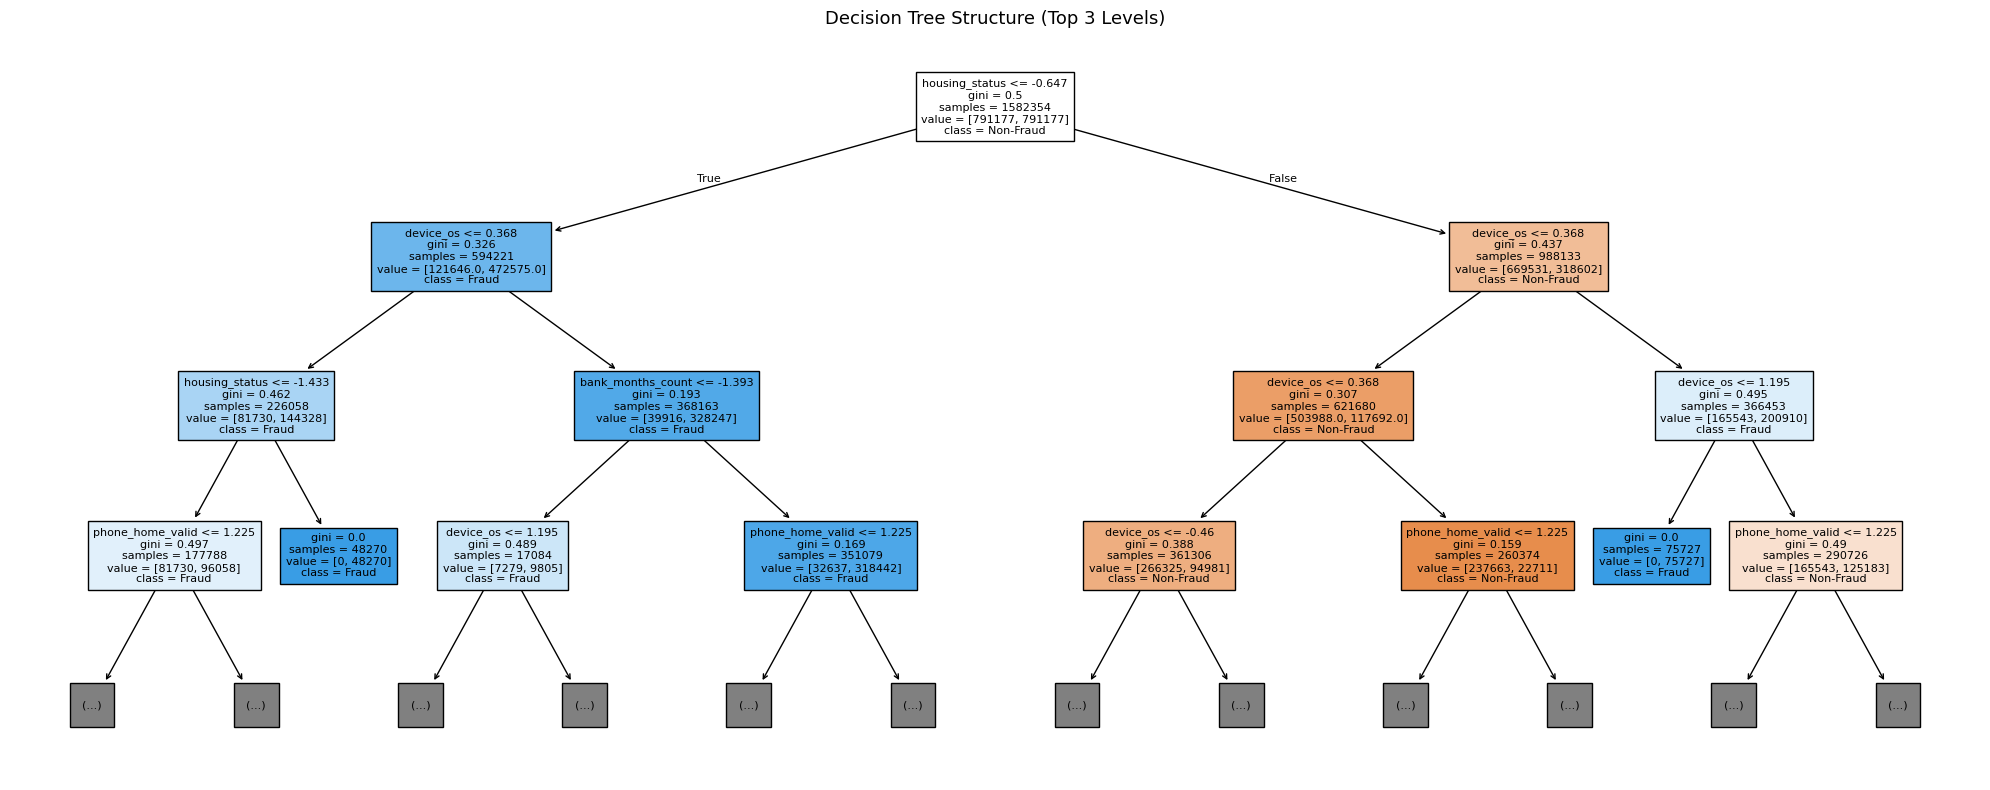

Tree structure saved ✓


In [ ]:
plt.figure(figsize=(20,8))
plot_tree(
    dt_model,
    max_depth     = 3,
    feature_names = X.columns,
    class_names   = ['Non-Fraud', 'Fraud'],
    filled        = True,
    fontsize      = 8
)
plt.title('Decision Tree Structure (Top 3 Levels)', fontsize=13)
plt.tight_layout()
plt.savefig('dt_tree_structure.png', dpi=150, bbox_inches='tight')
plt.show()
print("Tree structure saved ✓")


In [ ]:
print("\n" + "="*55)
print("  DECISION TREE - FINAL SUMMARY (AUTO THRESHOLD)")
print("="*55)
print(f"  Features used   : {X.shape[1]}")
print(f"  Training size   : {X_train_resampled.shape[0]:,} rows (after SMOTE)")
print(f"  Test size       : {X_test_scaled.shape[0]:,} rows")
print(f"  Best Threshold  : {best_threshold:.4f}")
print(f"  Accuracy        : {accuracy_score(y_test, dt_pred)*100:.2f}%")
print(f"  Precision       : {precision_score(y_test, dt_pred)*100:.2f}%")
print(f"  Recall          : {recall_score(y_test, dt_pred)*100:.2f}%")
print(f"  F1-Score        : {f1_score(y_test, dt_pred)*100:.2f}%")
print(f"  ROC-AUC         : {roc_auc_score(y_test, dt_pred_prob)*100:.2f}%")
print(f"\n  Confusion Matrix:")
print(f"  True Negative  (TN) : {TN:,}")
print(f"  False Positive (FP) : {FP:,}")
print(f"  False Negative (FN) : {FN:,}")
print(f"  True Positive  (TP) : {TP:,}")
print(f"\n  Frauds correctly caught : {TP:,} / {TP+FN:,}")
print(f"  Frauds missed           : {FN:,} / {TP+FN:,}")
print("="*55)


  DECISION TREE - FINAL SUMMARY (AUTO THRESHOLD)
  Features used   : 26
  Training size   : 1,582,354 rows (after SMOTE)
  Test size       : 200,000 rows
  Best Threshold  : 0.7536
  Accuracy        : 97.37%
  Precision       : 11.22%
  Recall          : 20.04%
  F1-Score        : 14.38%
  ROC-AUC         : 78.11%

  Confusion Matrix:
  True Negative  (TN) : 194,296
  False Positive (FP) : 3,498
  False Negative (FN) : 1,764
  True Positive  (TP) : 442

  Frauds correctly caught : 442 / 2,206
  Frauds missed           : 1,764 / 2,206


In [ ]:
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             roc_auc_score, confusion_matrix,
                             RocCurveDisplay)

# Recalculate all metrics
models_results = {
    'Decision Tree': {
        'pred'     : dt_pred,
        'prob'     : dt_pred_prob,
        'threshold': 0.75,
        'color'    : 'green'
    },
    'Random Forest': {
        'pred'     : rf_pred,
        'prob'     : rf_pred_prob,
        'threshold': best_threshold,
        'color'    : 'blue'
    },
    'XGBoost': {
        'pred'     : xgb_pred,
        'prob'     : xgb_pred_prob,
        'threshold': 0.13,
        'color'    : 'purple'
    }
}

# Build comparison table
rows = []
for name, m in models_results.items():
    cm  = confusion_matrix(y_test, m['pred'])
    row = {
        'Model'        : name,
        'Threshold'    : m['threshold'],
        'Accuracy'     : accuracy_score(y_test, m['pred'])*100,
        'Precision'    : precision_score(y_test, m['pred'])*100,
        'Recall'       : recall_score(y_test, m['pred'])*100,
        'F1-Score'     : f1_score(y_test, m['pred'])*100,
        'ROC-AUC'      : roc_auc_score(y_test, m['prob'])*100,
        'Frauds Caught': cm[1][1],
        'Frauds Missed': cm[1][0],
        'False Alarms' : cm[0][1]
    }
    rows.append(row)

comparison_df = pd.DataFrame(rows)

print("="*80)
print("  FINAL MODEL COMPARISON - FRAUD DETECTION")
print("="*80)
print(comparison_df.round(2).to_string(index=False))
print("="*80)

  FINAL MODEL COMPARISON - FRAUD DETECTION
        Model  Threshold  Accuracy  Precision  Recall  F1-Score  ROC-AUC  Frauds Caught  Frauds Missed  False Alarms
Decision Tree       0.75     97.37      11.22   20.04     14.38    78.11            442           1764          3498
Random Forest       0.75     97.83      14.49   19.81     16.74    83.45            437           1769          2579
      XGBoost       0.13     97.39      14.71   28.42     19.38    86.37            627           1579          3636


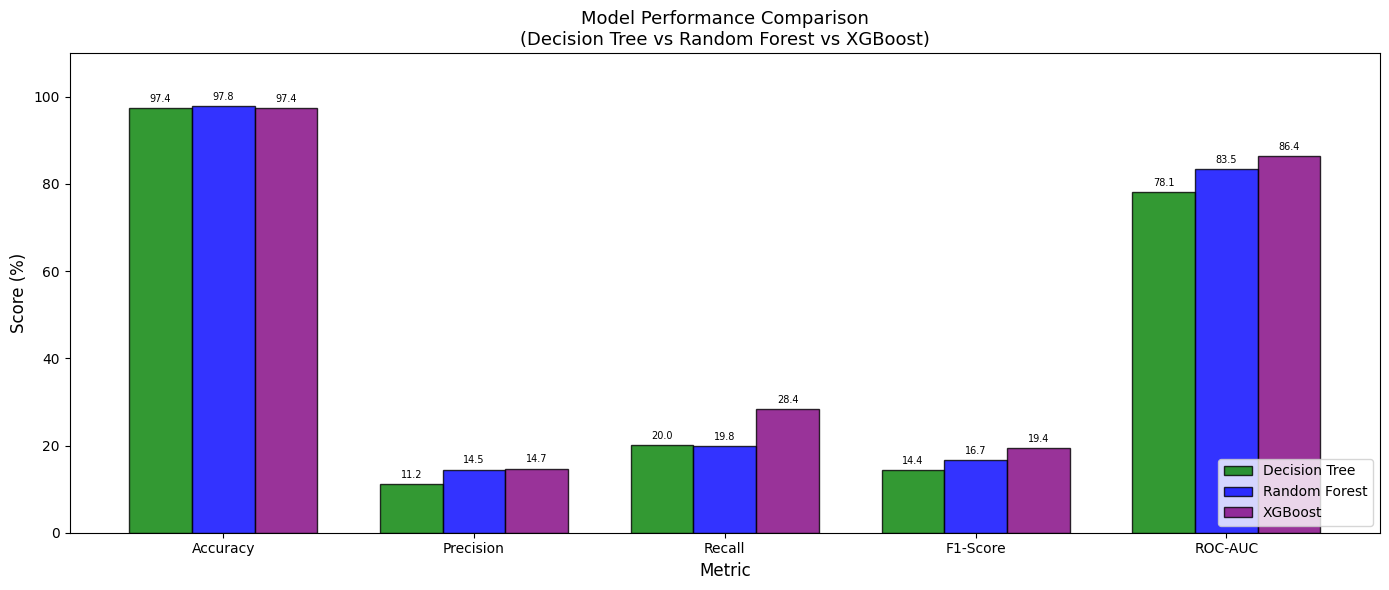

Bar chart saved ✓


In [ ]:
metrics    = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
x          = np.arange(len(metrics))
width      = 0.25

fig, ax    = plt.subplots(figsize=(14,6))

bars1 = ax.bar(x - width, comparison_df[comparison_df['Model']=='Decision Tree'][metrics].values[0],
               width, label='Decision Tree', color='green',  alpha=0.8, edgecolor='black')
bars2 = ax.bar(x,         comparison_df[comparison_df['Model']=='Random Forest'][metrics].values[0],
               width, label='Random Forest', color='blue',   alpha=0.8, edgecolor='black')
bars3 = ax.bar(x + width, comparison_df[comparison_df['Model']=='XGBoost'][metrics].values[0],
               width, label='XGBoost',       color='purple', alpha=0.8, edgecolor='black')

ax.set_xlabel('Metric', fontsize=12)
ax.set_ylabel('Score (%)', fontsize=12)
ax.set_title('Model Performance Comparison\n(Decision Tree vs Random Forest vs XGBoost)',
             fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend(loc='lower right')
ax.set_ylim(0, 110)

# Add value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.1f}',
                    xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig('model_comparison_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("Bar chart saved ✓")

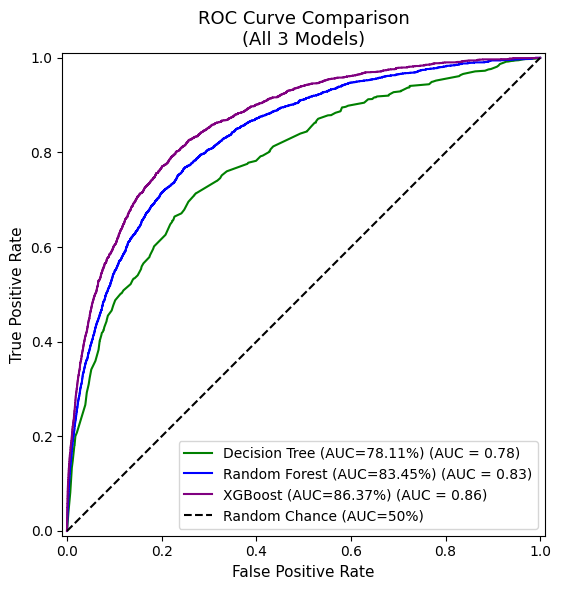

Combined ROC curve saved ✓


In [ ]:
fig, ax = plt.subplots(figsize=(8,6))

RocCurveDisplay.from_predictions(
    y_test, dt_pred_prob,
    name  = f'Decision Tree (AUC=78.11%)',
    ax    = ax, color='green'
)
RocCurveDisplay.from_predictions(
    y_test, rf_pred_prob,
    name  = f'Random Forest (AUC=83.45%)',
    ax    = ax, color='blue'
)
RocCurveDisplay.from_predictions(
    y_test, xgb_pred_prob,
    name  = f'XGBoost (AUC=86.37%)',
    ax    = ax, color='purple'
)
ax.plot([0,1], [0,1], 'k--', label='Random Chance (AUC=50%)')
ax.set_title('ROC Curve Comparison\n(All 3 Models)', fontsize=13)
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('all_models_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("Combined ROC curve saved ✓")

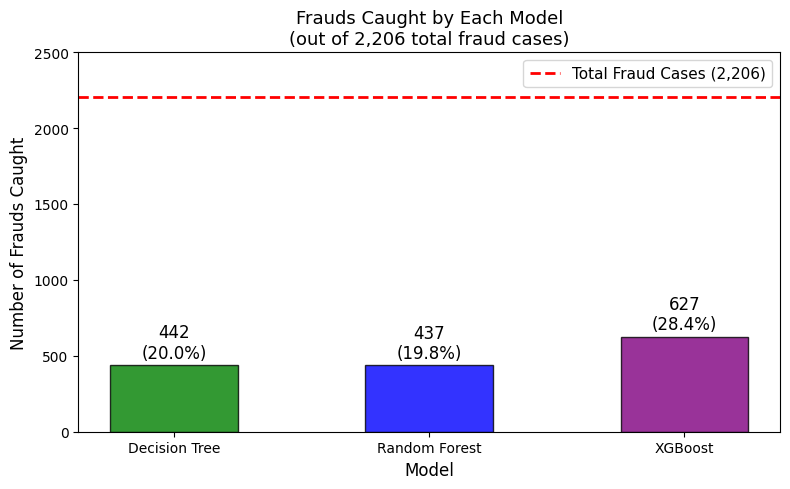

Frauds caught chart saved ✓


In [ ]:
fig, ax   = plt.subplots(figsize=(8,5))
model_names    = ['Decision Tree', 'Random Forest', 'XGBoost']
frauds_caught  = [442, 437, 627]
colors         = ['green', 'blue', 'purple']

bars = ax.bar(model_names, frauds_caught,
              color=colors, alpha=0.8,
              edgecolor='black', width=0.5)

for bar, caught in zip(bars, frauds_caught):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 20,
        f'{caught}\n({caught/2206*100:.1f}%)',
        ha='center', va='bottom', fontsize=12
    )

ax.axhline(y=2206, color='red',
           linestyle='--', linewidth=2,
           label='Total Fraud Cases (2,206)')
ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Number of Frauds Caught', fontsize=12)
ax.set_title('Frauds Caught by Each Model\n(out of 2,206 total fraud cases)',
             fontsize=13)
ax.legend(fontsize=11)
ax.set_ylim(0, 2500)
plt.tight_layout()
plt.savefig('frauds_caught_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Frauds caught chart saved ✓")


In [ ]:
print("\n" + "="*55)
print("  FINAL MODEL RANKING")
print("="*55)
print(f"\n  🥇 1st : XGBoost")
print(f"          ROC-AUC        : 86.37%")
print(f"          Recall         : 28.42%")
print(f"          Frauds Caught  : 627/2206")
print(f"          F1-Score       : 19.38%")

print(f"\n  🥈 2nd : Random Forest")
print(f"          ROC-AUC        : 83.45%")
print(f"          Recall         : 19.81%")
print(f"          Frauds Caught  : 437/2206")
print(f"          F1-Score       : 16.74%")

print(f"\n  🥉 3rd : Decision Tree")
print(f"          ROC-AUC        : 78.11%")
print(f"          Recall         : 20.04%")
print(f"          Frauds Caught  : 442/2206")
print(f"          F1-Score       : 14.38%")

print(f"\n  CONCLUSION:")
print(f"  XGBoost is the best model for fraud detection")
print(f"  with highest ROC-AUC and most frauds caught")
print("="*55)


  FINAL MODEL RANKING

  🥇 1st : XGBoost
          ROC-AUC        : 86.37%
          Recall         : 28.42%
          Frauds Caught  : 627/2206
          F1-Score       : 19.38%

  🥈 2nd : Random Forest
          ROC-AUC        : 83.45%
          Recall         : 19.81%
          Frauds Caught  : 437/2206
          F1-Score       : 16.74%

  🥉 3rd : Decision Tree
          ROC-AUC        : 78.11%
          Recall         : 20.04%
          Frauds Caught  : 442/2206
          F1-Score       : 14.38%

  CONCLUSION:
  XGBoost is the best model for fraud detection
  with highest ROC-AUC and most frauds caught
